## Load in Test Case & Run Power Flow

In [1]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation
out_dir = project_dir / "out"
pert_path = project_dir / "2_noise_pert.py"

In [2]:
from calculate_metrics import calculate_metrics

In [3]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import andes

andes.config_logger(stream_level=30)

In [4]:
# import case file
case_path = andes.get_case(test_case_dir / "regf2_testbench.xlsx")

In [5]:
# TDS Constants
STEP_TIME = 0.01 # 10 ms

In [6]:
ss_true = andes.load(case_path, setup=False)

ss_true.setup()
ss_true.config.warn_abnormal = 0
ss_true.PFlow.run()
#ss_true.REGF2.set("Tr",1,0.01)


ss_true.TDS.config.tf = 20 # Baruzzi et al ran simulation for 9s after disturbance
ss_true.TDS.config.fixt = 1 # fixed step size
ss_true.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss_true.TDS.config.no_tqdm = 1
ss_true.TDS.config.criteria = 1
ss_true.TDS.run()

True

## Run TDS & Initial Results

In [7]:
ss = andes.load(case_path, pert=pert_path)
ss.REGF2.set("Tr",1,0.01)
print(ss.REGF2.Tr.v)

ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()

ss.TDS.config.tf = 20 # Baruzzi et al ran simulation for 9s after disturbance
ss.TDS.config.fixt = 1 # fixed step size
ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 1
ss.TDS.run()

[0.01]
pert() applied at grid_t=0.0
wrote: 0.20146927686808397, read back next call: [0.20146928]
pert() applied at grid_t=0.01
wrote: 0.2017546809034567, read back next call: [0.20175468]
pert() applied at grid_t=0.02
wrote: 0.20291418696800823, read back next call: [0.20291419]
pert() applied at grid_t=0.03
wrote: 0.2036652500547161, read back next call: [0.20366525]
pert() applied at grid_t=0.04
wrote: 0.20485976308177234, read back next call: [0.20485976]
pert() applied at grid_t=0.05
wrote: 0.2070037603534517, read back next call: [0.20700376]
pert() applied at grid_t=0.06
wrote: 0.20752440455366006, read back next call: [0.2075244]
pert() applied at grid_t=0.07
wrote: 0.21032227620943572, read back next call: [0.21032228]
pert() applied at grid_t=0.08
wrote: 0.212417372692218, read back next call: [0.21241737]
pert() applied at grid_t=0.09
wrote: 0.20887282108233357, read back next call: [0.20887282]
pert() applied at grid_t=0.1
wrote: 0.20636051436370165, read back next call: [0

System has been setup. Calling setup() twice is not allowed. To add devices, reload the case with setup=False, add devices, then call setup().


pert() applied at grid_t=0.28
wrote: 0.1980138483524558, read back next call: [0.19801385]
pert() applied at grid_t=0.29
wrote: 0.2018250740626586, read back next call: [0.20182507]
pert() applied at grid_t=0.3
wrote: 0.20308444024116876, read back next call: [0.20308444]
pert() applied at grid_t=0.31
wrote: 0.20606495240292233, read back next call: [0.20606495]
pert() applied at grid_t=0.32
wrote: 0.20624200897848882, read back next call: [0.20624201]
pert() applied at grid_t=0.33
wrote: 0.2038276834807542, read back next call: [0.20382768]
pert() applied at grid_t=0.34
wrote: 0.2062395185909869, read back next call: [0.20623952]
pert() applied at grid_t=0.35000000000000003
wrote: 0.2035672110420585, read back next call: [0.20356721]
pert() applied at grid_t=0.36
wrote: 0.2011939085726997, read back next call: [0.20119391]
pert() applied at grid_t=0.37
wrote: 0.20073808817112454, read back next call: [0.20073809]
pert() applied at grid_t=0.38
wrote: 0.20005034113422554, read back next

True

In [19]:
def visualize_cf_noise(noisy, true, var, figsize=(6,4)):
    fig, ax = plt.subplots(figsize=figsize)

    ax.set_title(f"{var}: Noisy vs. Noiseless Signal Inputs")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(f"{var} (p.u.)")

    # plot actual
    ax.plot(true.index, true, "s-", color="tab:blue",
                markersize=0.5, label="Noiseless Inputs", alpha=0.8)
    ax.plot(noisy.index, noisy, "s-", color="tab:orange",
                    markersize=0.5, label="Noisy Inputs", alpha=0.8)
    
    

    ax.legend(loc="lower right", fontsize=9, framealpha=0.9)


    plt.tight_layout()

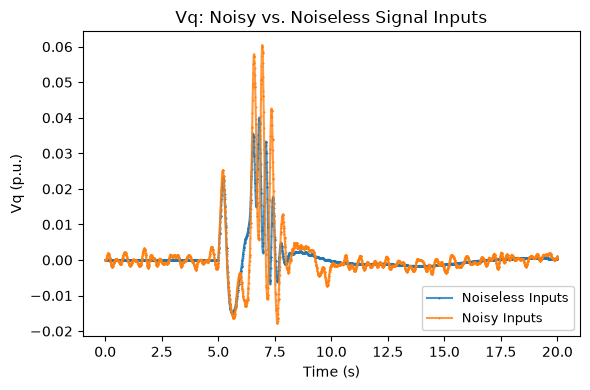

In [20]:
vq = ss.TDS.get_timeseries(ss.REGF2.vq)
vq_t = ss_true.TDS.get_timeseries(ss_true.REGF2.vq)

visualize_cf_noise(vq, vq_t, "Vq")

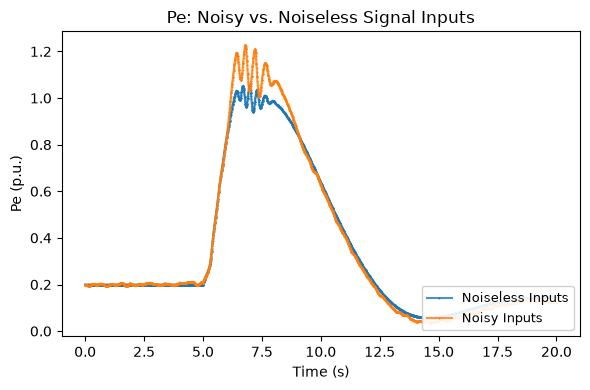

In [21]:
psen = ss.TDS.get_timeseries(ss.REGF2.Pe)
psen_t = ss_true.TDS.get_timeseries(ss_true.REGF2.Pe)

visualize_cf_noise(psen, psen_t, "Pe")

In [13]:
psen

,1
0.000000,0.200000
0.000100,0.200000
0.010100,0.199952
0.020100,0.199840
0.030100,0.199676
...,...
19.976867,0.124023
19.986867,0.123564
19.996867,0.123125
19.999900,0.122988


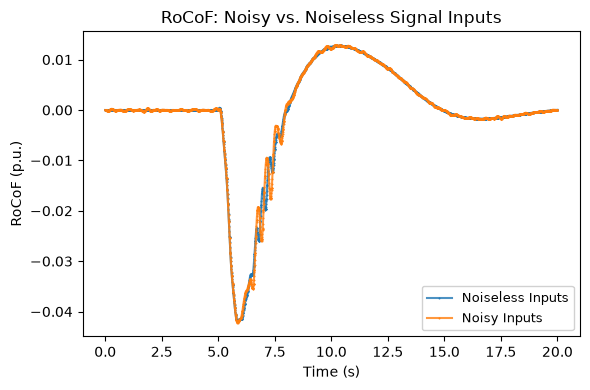

In [22]:
a1 = ss.TDS.get_timeseries(ss.BusROCOF.Wf_y)
a2 = ss_true.TDS.get_timeseries(ss_true.BusROCOF.Wf_y)

visualize_cf_noise(a1, a2, "RoCoF")

## Metrics

In [25]:
metrics_df, h_series = calculate_metrics(ss, True)
metrics_df

/Users/scarlett/Programming/2026 Power Grid Research/PV-virtual-inertia-estimation-noise-lag/andes_env/lib/python3.11/site-packages/statsmodels/tools/eval_measures.py:40: RuntimeWarning: overflow encountered in square
  return np.mean((x1 - x2) ** 2, axis=axis)


,Tr (s),Pref,Peak Inertial Power,Power Available,M_RMSE (s),Max RoCoF,Nadir,Settling Time (s)
0,0.01,0.2,1.226813,1.0,inf,0.042192,0.937545,20.0


In [26]:
metrics_true, h_true = calculate_metrics(ss_true, True)

/Users/scarlett/Programming/2026 Power Grid Research/PV-virtual-inertia-estimation-noise-lag/andes_env/lib/python3.11/site-packages/statsmodels/tools/eval_measures.py:40: RuntimeWarning: overflow encountered in square
  return np.mean((x1 - x2) ** 2, axis=axis)
/Users/scarlett/Programming/2026 Power Grid Research/PV-virtual-inertia-estimation-noise-lag/andes_env/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

H_gfm = ss.REGF2.get("mf", 1)
H_t = h_series

plot_title = f"Nominal ({H_gfm}s) vs. Estimated Inertia"
ax.set_title(plot_title)
ax.set_xlabel("Time (s)")
ax.set_ylabel("H (s)")

# plot actual
ax.plot(H_t.index, H_t, "s-", color="tab:blue", markersize=1.8, label = f"$H_{{estimated}}$")

plt.axline((0, H_gfm), slope=0, color="orange", linestyle=":", label=f"$H_{{nominal}}$")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

#ax.axvspan(0, time_invalid, color='gray', alpha=0.2)
#plt.xlim(0, 6)
#plt.ylim(-1, 50)
plt.tight_layout()

#plt.savefig(f'{out_dir}/1_testbench_figs/{plot_title}.png', dpi=300, bbox_inches='tight')

In [ ]:
visualize_cf_noise(h_series, h_true, "Estimated Inertia")

In [ ]:
ss_true.TDS.plot(ss.Bus.v)

# Temp

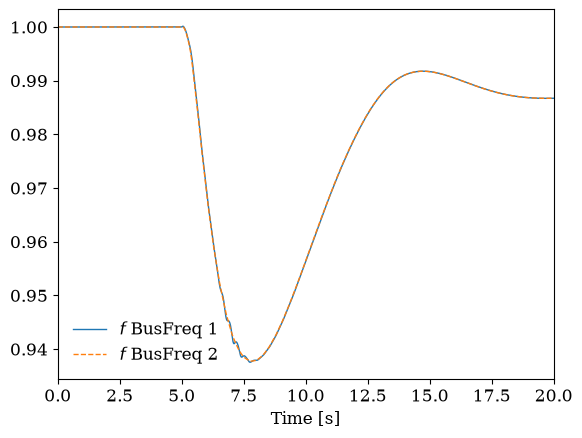

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [23]:
ss_true.TDS.plot(ss_true.BusFreq.f)

In [24]:
metrics_true

NameError: name 'metrics_true' is not defined